In [10]:
import sys

sys.path.insert(1, '../ML_pipeline')

import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE

### Load in feature data and create an array of hand-selected features

In [11]:
full_df = pd.read_csv('../ML_pipeline/features.csv')

device_list = ['hand',
               'chest',
               'ankle']

axes_list = ['x',
             'y',
             'z',
             'amp']

sensor_list = ['acc16',
               'gyro']

stat_list = ['mean',
             'hmean',
             'std',
             'max',
             'min',
             'median',
             'p2p',
             'mad',
             'iqr',
             'sum_abs',
             'mean_energy',
             'skew',
             'kurtosis']

feature_list = []

for stat in stat_list:
    feature_list.append('heart_rate_'+stat)

for device in device_list:
    for sensor in sensor_list:
        
        for axis in axes_list:
            for stat in stat_list:
                label = '_'.join([device,sensor,axis,stat])
                feature_list.append(label)
        
        for pair in ['xy','xz','yz']:
            label = '_'.join([device,sensor,'corr',pair])


X = full_df[feature_list]
y = full_df['activity_id']
groups = full_df['interval_id']

### Loop through sets of hyperparameters to train the model on, print out accuracies

In [12]:
print(f"X shape: {X.shape}")
print("Class counts:")
print(y.value_counts().sort_index())

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

def run_KNN(n_neighbors=5,weights='uniform'):

    rf_pipeline = Pipeline([
        (
            "KNN",
            KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights=weights,
                n_jobs=-1,
            ),
        ),
    ])

    rf_pipeline.fit(X_train, y_train)
    y_pred = rf_pipeline.predict(X_test)

    labels_sorted = np.sort(np.unique(np.concatenate([y_test.to_numpy(), y_pred])))
    cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=labels_sorted),
    index=[f"true_{lbl}" for lbl in labels_sorted],
    columns=[f"pred_{lbl}" for lbl in labels_sorted],
    )

    acc_score = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)

    return acc_score,report,cm


#loop through hyperparameters
k_vals = [5,10,20,30,50]
weight_vals = ['uniform','distance']

acc_dict = {}
report_dict = {}
cm_dict = {}

for weights in weight_vals:
    for k in k_vals:
        acc_score,report,cm = run_KNN(n_neighbors=k,weights=weights)

        label = weights + '-' + str(k)
        acc_dict[label] = acc_score
        report_dict[label] = report
        cm_dict[label] = cm


print(acc_dict)
print(report_dict['uniform-5'])
print(cm_dict['uniform-5'])

X shape: (15649, 325)
Class counts:
activity_id
1.0     1599
2.0     1539
3.0     1563
4.0     1992
5.0      756
6.0     1320
7.0     1521
12.0     887
13.0     771
16.0    1426
17.0    1973
24.0     302
Name: count, dtype: int64
{'uniform-5': 0.6577684463107378, 'uniform-10': 0.6697660467906419, 'uniform-20': 0.6757648470305939, 'uniform-30': 0.6739652069586083, 'uniform-50': 0.6823635272945411, 'distance-5': 0.6574685062987402, 'distance-10': 0.6631673665266946, 'distance-20': 0.674865026994601, 'distance-30': 0.6751649670065987, 'distance-50': 0.6808638272345531}
              precision    recall  f1-score   support

         1.0       1.00      0.89      0.94       686
         2.0       0.81      0.54      0.65       462
         3.0       0.00      0.00      0.00         0
         4.0       0.00      0.00      0.00         0
         5.0       1.00      0.96      0.98       281
         6.0       0.53      0.83      0.65       234
         7.0       0.96      0.40      0.57     

### Make the 2D projection of activities

In [13]:
ind = np.arange(0,len(X))
ind_pick = np.random.choice(ind,size=3000)

X_plot = X.iloc[ind_pick]
y_plot = y.iloc[ind_pick]

labels = y_plot.unique()
#labels.sort()

tsne = TSNE(n_components=2, random_state=0)
X_2d = tsne.fit_transform(X_plot)

print(labels)


[ 2. 16.  3. 17. 13. 12.  6.  1.  4.  5.  7. 24.]


C:\Users\Charlie\AppData\Local\Temp\ipykernel_39480\3892102641.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_2d[y_plot == i, 0], X_2d[y_plot == i, 1], c=c, label=activity_map[label],s=3)


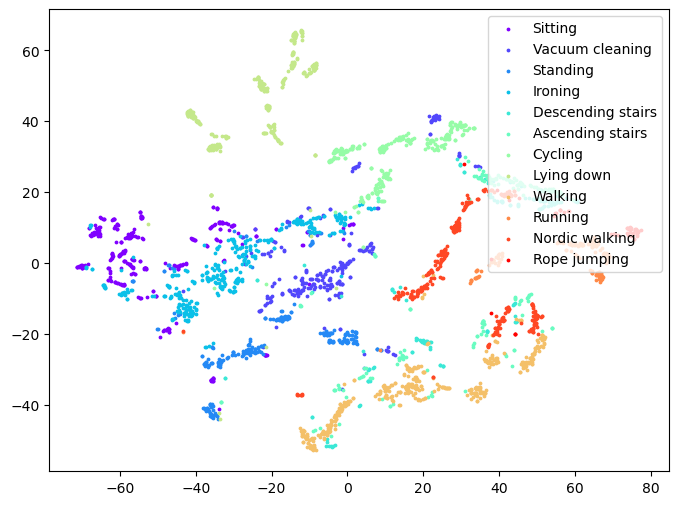

In [14]:
activity_map = {
    0: 'Transient/Break', 1: 'Lying down', 2: 'Sitting', 3: 'Standing', 
    4: 'Walking', 5: 'Running', 6: 'Cycling', 7: 'Nordic walking', 
    9: 'Watching TV', 10: 'Computer work', 11: 'Car driving', 
    12: 'Ascending stairs', 13: 'Descending stairs', 16: 'Vacuum cleaning', 
    17: 'Ironing', 18: 'Folding laundry', 19: 'House cleaning', 
    20: 'Playing soccer', 24: 'Rope jumping'
}

from matplotlib import pyplot as plt
plt.figure(figsize=(8, 6))

cmap = plt.get_cmap('rainbow')
colors = cmap(np.arange(0,len(labels))/(len(labels)-1))
for i, c, label in zip(labels, colors, labels):
    plt.scatter(X_2d[y_plot == i, 0], X_2d[y_plot == i, 1], c=c, label=activity_map[label],s=3)
plt.legend()
plt.show()

### Repeat the same analysis but with activities condensed into three groups

In [15]:
activity_groups = {'low_activity':[1,2,3], #lying, sitting, standing
                   'med_activity':[4,7,12,13,16,17], #walking, nordic walking, ascending stairs, descending stairs, vacuum cleaning, ironing
                   'high_activity':[5,6,24] #running, cycling, rope jumping
                   } 

for group in activity_groups.keys():
    for id in activity_groups[group]:
        y.replace(to_replace=id,value=group,inplace=True)

y

0         low_activity
1         low_activity
2         low_activity
3         low_activity
4         low_activity
             ...      
15644    high_activity
15645    high_activity
15646    high_activity
15647    high_activity
15648    high_activity
Name: activity_id, Length: 15649, dtype: object

In [16]:
print(f"X shape: {X.shape}")
print("Class counts:")
print(y.value_counts().sort_index())

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

def run_KNN(n_neighbors=5,weights='uniform'):

    rf_pipeline = Pipeline([
        (
            "KNN",
            KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights=weights,
                n_jobs=-1,
            ),
        ),
    ])

    rf_pipeline.fit(X_train, y_train)
    y_pred = rf_pipeline.predict(X_test)

    labels_sorted = np.sort(np.unique(np.concatenate([y_test.to_numpy(), y_pred])))
    cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=labels_sorted),
    index=[f"true_{lbl}" for lbl in labels_sorted],
    columns=[f"pred_{lbl}" for lbl in labels_sorted],
    )

    acc_score = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)

    return acc_score,report,cm


#loop through hyperparameters
k_vals = [5,10,20,30,50]
weight_vals = ['uniform','distance']

acc_dict = {}
report_dict = {}
cm_dict = {}

for weights in weight_vals:
    for k in k_vals:
        acc_score,report,cm = run_KNN(n_neighbors=k,weights=weights)

        label = weights + '-' + str(k)
        acc_dict[label] = acc_score
        report_dict[label] = report
        cm_dict[label] = cm

print(acc_dict)
print(report_dict['uniform-5'])
print(cm_dict['uniform-5'])

X shape: (15649, 325)
Class counts:
activity_id
high_activity    2378
low_activity     4701
med_activity     8570
Name: count, dtype: int64
{'uniform-5': 0.8719256148770246, 'uniform-10': 0.8845230953809238, 'uniform-20': 0.8860227954409118, 'uniform-30': 0.8797240551889622, 'uniform-50': 0.8785242951409719, 'distance-5': 0.8719256148770246, 'distance-10': 0.8785242951409719, 'distance-20': 0.8863227354529094, 'distance-30': 0.882123575284943, 'distance-50': 0.8779244151169766}
               precision    recall  f1-score   support

high_activity       0.74      0.91      0.81       515
 low_activity       0.98      0.82      0.89      1148
 med_activity       0.86      0.90      0.88      1671

     accuracy                           0.87      3334
    macro avg       0.86      0.88      0.86      3334
 weighted avg       0.88      0.87      0.87      3334

                    pred_high_activity  pred_low_activity  pred_med_activity
true_high_activity                 468              

In [17]:
ind = np.arange(0,len(X))
ind_pick = np.random.choice(ind,size=3000)

X_plot = X.iloc[ind_pick]
y_plot = y.iloc[ind_pick]

labels = y_plot.unique()
#labels.sort()

tsne = TSNE(n_components=2, random_state=0)
X_2d = tsne.fit_transform(X_plot)

print(labels)


['high_activity' 'low_activity' 'med_activity']


C:\Users\Charlie\AppData\Local\Temp\ipykernel_39480\903677911.py:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_2d[y_plot == i, 0], X_2d[y_plot == i, 1], c=c, label=label,s=3)


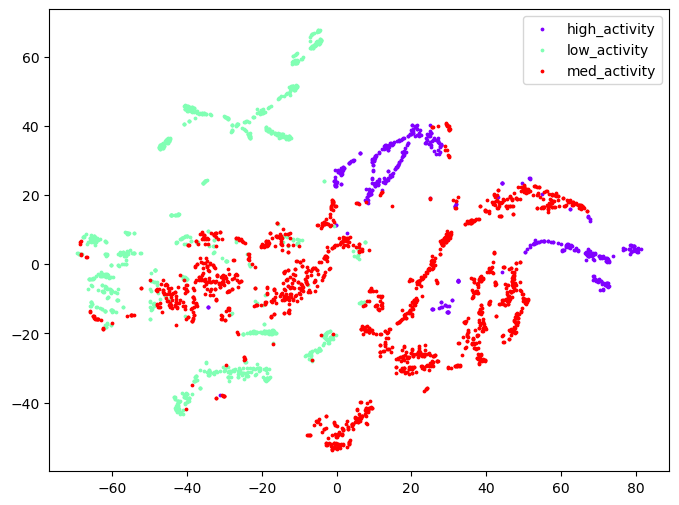

In [18]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 6))

cmap = plt.get_cmap('rainbow')
colors = cmap(np.arange(0,len(labels))/(len(labels)-1))
for i, c, label in zip(labels, colors, labels):
    plt.scatter(X_2d[y_plot == i, 0], X_2d[y_plot == i, 1], c=c, label=label,s=3)
plt.legend()
plt.show()